In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def objective(x, y):
    """
    Objective function of x and y (float scalars or ndarray)
    """
    return 3*(x-1)**2 + y**2

def get_dummy_history() -> dict:
    """
    Fake history - some sequence of solutions (x,y) via iterations and corresponding objective values
    return: dictionary with history
    """
    solutions = np.asarray([[-8,12],[-5,9],[-3,2],[-1,1]])
    history = {idx: {'solution': solutions[idx,:],
                     'objective': objective(*solutions[idx,:])
                    }
                    for idx in range(len(solutions))}
    return history

def plot_history(title: str, objective, bounds: np.ndarray, step_x: float, step_y: float, history: dict):
    """
    Matplotlib plot of solution sequence and objective level curves (contours)
    :param str title: Title of figure
    :param objective: Objective function to be calcutated for input in runtime
    :param ndarray bounds: Axes bounds
    :param float step_x: step for meshgrid via horizontal axis
    :param float step_y: step for meshgrid via vertical axis
    :param dict history: dictionary with minimization history
    """

    xaxis_vals = np.arange(bounds[0,0], bounds[0,1], step_x)
    yaxis_vals = np.arange(bounds[1,0], bounds[1,1], step_y)
    xx, yy = np.meshgrid(xaxis_vals, yaxis_vals)
    target_grid_vals = objective(xx, yy)

    colorlist = ["darkblue","blue","aqua","lawngreen", "gold","darkorange","brown" ]
    newcmp = LinearSegmentedColormap.from_list("testCmap", colors=colorlist, N=256)
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    xmin, xmax, ymin, ymax = np.amin(xx), np.amax(xx), np.amin(yy), np.amax(yy)
    
    # set up levels in different way to provide list|ndarray of particular values 
    # (not a number of levels as in a line below)
    contours = ax.contour(xx, yy, target_grid_vals, levels=50, cmap=newcmp, alpha=0.4)
    plt.clabel(contours, inline=1, fontsize=8)

    solutions_x = [v['solution'][0] for k,v in history.items()]
    solutions_y = [v['solution'][1] for k,v in history.items()]
    plt.plot(solutions_x, solutions_y, '.-', color='r')
    plt.title(title)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])
    plt.show()


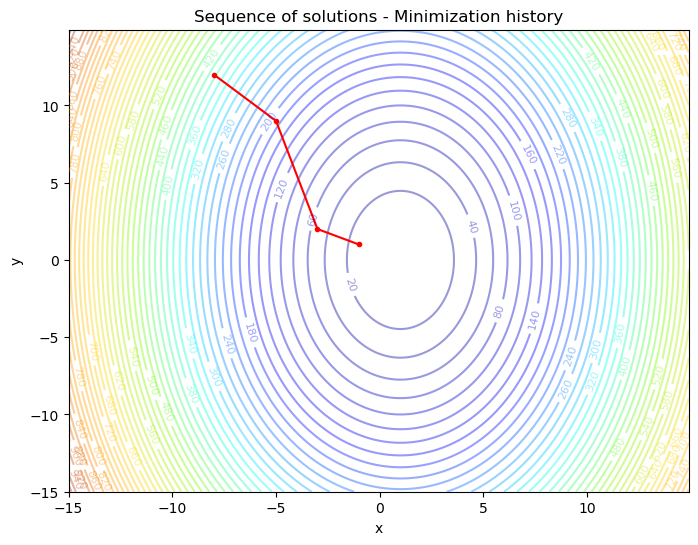

In [2]:
steps = (0.1, 0.1)
bounds = np.asarray([[-15.0, 15.0], [-15.0, 15.0]])

initial_solution = np.asarray((-5., 40.))
plot_history('Sequence of solutions - Minimization history', objective, bounds, *steps, get_dummy_history())